In [99]:
### System imports
import sys, os, shutil
import glob

import numpy as np
import pandas as pd
import tables_io

from MultiSurveyErrorModel import MultiSurveyErrorModel
from UMAPEstimator import UMAPEstimator

import matplotlib.pyplot as plt
plt.style.use("/global/homes/s/sajkov/umap_nz_cal.mplstyle")

### Initialize random state
seed = 42
rng = np.random.default_rng(seed = seed)

### Specify outputs directory
outputs_directory = f"/pscratch/sd/s/sajkov/analysis_pipeline/runs/fix_photometry"
os.makedirs(outputs_directory, exist_ok = True)

In [96]:

import time
date = "test_photom_outputs_10Jul26"

def timestamp():
    return(f"[{time.strftime("%H:%M:%S", time.localtime())}]")

def timer(start_time, return_tuple = False):
    elapsed_time = time.time() - start_time

    hours = elapsed_time//3600
    minutes = (elapsed_time//60)%60
    seconds = elapsed_time - 3600 * hours - 60 * minutes
    
    if return_tuple:
        return (hours, minutes, seconds)
    
    if hours > 0:
        return f'{hours:.0f}h {minutes:.0f}m {seconds:.1f}s'
    
    if minutes > 0:
        return f'{minutes:.0f}m {seconds:.1f}s'
    
    return f'{seconds:.1f}s'

start_time = time.time()

In [101]:
PHOTOMETRY_DeepField_asinh_noisy     = tables_io.read("/pscratch/sd/s/sajkov/analysis_pipeline/runs/test_photom_outputs_10Jul26/PHOTOMETRY_DeepField_asinh_noisy_test_photom_outputs_10Jul26.pq")
PHOTOMETRY_WideFastDeep_asinh_noisy  = tables_io.read("/pscratch/sd/s/sajkov/analysis_pipeline/runs/test_photom_outputs_10Jul26/PHOTOMETRY_WideFastDeep_asinh_noisy_test_photom_outputs_10Jul26.pq")
PHOTOMETRY_DeepField_pogson_noisy    = tables_io.read("/pscratch/sd/s/sajkov/analysis_pipeline/runs/test_photom_outputs_10Jul26/PHOTOMETRY_DeepField_pogson_noisy_test_photom_outputs_10Jul26.pq")
PHOTOMETRY_WideFastDeep_pogson_noisy = tables_io.read("/pscratch/sd/s/sajkov/analysis_pipeline/runs/test_photom_outputs_10Jul26/PHOTOMETRY_WideFastDeep_pogson_noisy_test_photom_outputs_10Jul26.pq")

REDSHIFTS_DeepField    = np.load("/pscratch/sd/s/sajkov/analysis_pipeline/runs/test_photom_outputs_10Jul26/TRUEREDSHIFTS_DeepField.npy")
REDSHIFTS_WideFastDeep = np.load("/pscratch/sd/s/sajkov/analysis_pipeline/runs/test_photom_outputs_10Jul26/TRUEREDSHIFTS_WideFastDeep.npy")

column_list None
column_list None
column_list None
column_list None


/tmp/ipykernel_88965/415148355.py:14: UserWarning: Adding colorbar to a different Figure <Figure size 2050x1000 with 3 Axes> than <Figure size 2050x1000 with 3 Axes> which fig.colorbar is called on.
  fig.colorbar(mappable = mappable, cax = axs[2], label = "Number of sources")


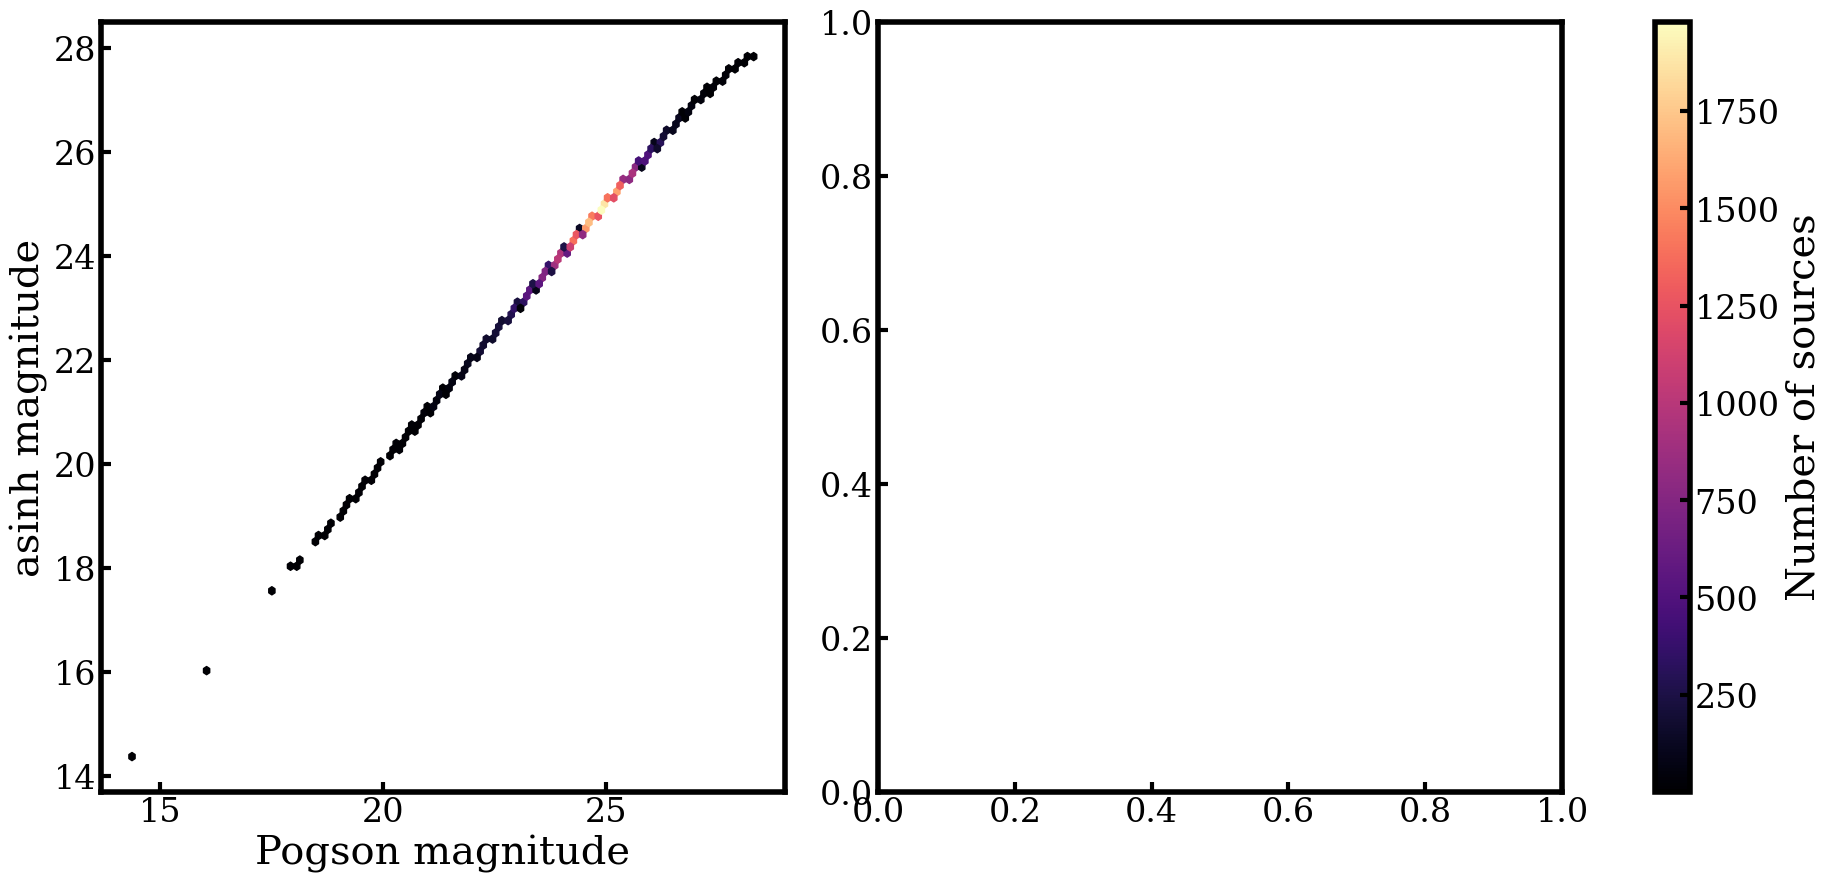

In [92]:
fig = plt.figure(figsize = (20.5, 10))
axs = fig.subplots(1, 3, width_ratios = (10, 10, 0.5))

band = "HSC_MB_05"

axs[0].hexbin(PHOTOMETRY_DeepField_pogson_noisy[band], PHOTOMETRY_DeepField_asinh_noisy[band], mincnt = 1)
axs[0].set_xlabel("Pogson magnitude")
axs[0].set_ylabel("asinh magnitude")

# mappable = axs[1].hexbin(PHOTOMETRY_WideFastDeep_pogson_noisy[band], PHOTOMETRY_WideFastDeep_asinh_noisy[band], mincnt = 1)
# axs[1].set_xlabel("Pogson magnitude")
# axs[1].set_ylabel("asinh magnitude")

fig.colorbar(mappable = mappable, cax = axs[2], label = "Number of sources")

In [102]:

# ----------------------------------------------------------------------------------------------- #
# Section 3: Estimate redshfits with UMAPs                                                        #
# ----------------------------------------------------------------------------------------------- #

print(timestamp(), "Preparing input data for UMAPs", end = "\r")

### Prepare input data
TRAINING_DATA_UMAP = PHOTOMETRY_DeepField_asinh_noisy

TRAINING_PHOTOMETRY_UMAP = TRAINING_DATA_UMAP[BANDS_WideFastDeep]
TRAINING_PHOTOMERRS_UMAP = TRAINING_DATA_UMAP[ERR_BANDS_WideFastDeep]

TRAINING_REDSHIFTS_UMAP_specZs  = np.load("/pscratch/sd/s/sajkov/analysis_pipeline/runs/test_photom_outputs_10Jul26/TRUEREDSHIFTS_DeepField.npy")
TRAINING_REDSHIFTS_UMAP_photoZs = np.load("/pscratch/sd/s/sajkov/analysis_pipeline/runs/test_photom_outputs_10Jul26/TRUEREDSHIFTS_WideFastDeep.npy")

ESTIMATION_DATA_UMAP = PHOTOMETRY_WideFastDeep_asinh_noisy

ESTIMATION_PHOTOMETRY_UMAP = ESTIMATION_DATA_UMAP[BANDS_WideFastDeep]
ESTIMATION_PHOTOMERRS_UMAP = ESTIMATION_DATA_UMAP[ERR_BANDS_WideFastDeep]
ESTIMATION_REDSHIFTS_UMAP = REDSHIFTS_WideFastDeep

COLORNAMES_WideFastDeep = [f"{BANDS_WideFastDeep[i].split('_')[-1]}-{BANDS_WideFastDeep[i + 1].split('_')[-1]}"
                           for i in range(len(BANDS_WideFastDeep) - 1)]

COLERRNAMES_WideFastDeep = [f"{BANDS_WideFastDeep[i].split('_')[-1]}-{BANDS_WideFastDeep[i + 1].split('_')[-1]}_err"
                           for i in range(len(BANDS_WideFastDeep) - 1)]

TRAINING_COLORS_UMAP = pd.DataFrame(
    {COLORNAMES_WideFastDeep[i]:
        TRAINING_PHOTOMETRY_UMAP[BANDS_WideFastDeep[i]] - TRAINING_PHOTOMETRY_UMAP[BANDS_WideFastDeep[i + 1]]
            for i in range(len(BANDS_WideFastDeep) - 1)}
)

TRAINING_COLERRS_UMAP = pd.DataFrame(
    {COLERRNAMES_WideFastDeep[i]:
        np.clip(np.sqrt(TRAINING_PHOTOMERRS_UMAP[ERR_BANDS_WideFastDeep[i]]**2 + TRAINING_PHOTOMERRS_UMAP[ERR_BANDS_WideFastDeep[i + 1]]**2),
                None, 0.05)
            for i in range(len(ERR_BANDS_WideFastDeep) - 1)}
)

ESTIMATION_COLORS_UMAP = pd.DataFrame(
    {COLORNAMES_WideFastDeep[i]:
        ESTIMATION_PHOTOMETRY_UMAP[BANDS_WideFastDeep[i]] - ESTIMATION_PHOTOMETRY_UMAP[BANDS_WideFastDeep[i + 1]]
            for i in range(len(BANDS_WideFastDeep) - 1)}
)

ESTIMATION_COLERRS_UMAP = pd.DataFrame(
    {COLERRNAMES_WideFastDeep[i]:
        np.clip(np.sqrt(ESTIMATION_PHOTOMERRS_UMAP[ERR_BANDS_WideFastDeep[i]]**2 + ESTIMATION_PHOTOMERRS_UMAP[ERR_BANDS_WideFastDeep[i + 1]]**2),
                None, 0.05)
            for i in range(len(ERR_BANDS_WideFastDeep) - 1)}
)

TRAINING_COLORS_UMAP.to_parquet(f"{outputs_directory}/TRAINING_COLORS_UMAP_{date}.pq")
TRAINING_COLERRS_UMAP.to_parquet(f"{outputs_directory}/TRAINING_COLERRS_UMAP_{date}.pq")
np.save(f"{outputs_directory}/TRAINING_REDSHIFTS_UMAP_specZs_{date}",  TRAINING_REDSHIFTS_UMAP_specZs,  allow_pickle = True)
np.save(f"{outputs_directory}/TRAINING_REDSHIFTS_UMAP_photoZs_{date}", TRAINING_REDSHIFTS_UMAP_photoZs, allow_pickle = True)

ESTIMATION_COLORS_UMAP.to_parquet(f"{outputs_directory}/ESTIMATION_COLORS_UMAP_{date}.pq")
ESTIMATION_COLERRS_UMAP.to_parquet(f"{outputs_directory}/ESTIMATION_COLERRS_UMAP_{date}.pq")
np.save(f"{outputs_directory}/ESTIMATION_REDSHIFTS_UMAP_{date}", ESTIMATION_REDSHIFTS_UMAP, allow_pickle = True)

print(timestamp(), "Prepared input data for UMAPs. Time elapsed: ", timer(start_time))

### Set UMAP parameters
ambient_metric_umap = "manhattan_weighted_linear"
n_neighbors_umap    = 80
min_dist            = 0.0

n_neighbors_knn = 10
metric_p_knn   = 2

precision_gauss_kde = 0.01

print(timestamp(), "Building, and getting redshifts from, spec-z UMAP", end = "\r")

### Buld a UMAP from the training photometry, colored with spectrosopic redshifts
informedReducerPath_UMAP_wSpecZs      = f"{outputs_directory}/informedReducer_UMAP_wSpecZs_{date}.pkl"
informedEmbeddingPath_UMAP_wSpecZs    = f"{outputs_directory}/informedEmbedding_UMAP_wSpecZs_{date}.pq"
informedkNNRegressorPath_UMAP_wSpecZs = f"{outputs_directory}/informedkNNRegressor_UMAP_wSpecZs_{date}.pkl"

estimatedEmbeddingPath_UMAP_wSpecZs     = f"{outputs_directory}/estimatedEmbedding_UMAP_wSpecZs_{date}.pq"
estimatedPhotoZMediansPath_UMAP_wSpecZs = f"{outputs_directory}/estimatedPhotoZMedians_UMAP_wSpecZs_{date}.pq"
estimatedPhotoZPDFsPath_UMAP_wSpecZs    = f"{outputs_directory}/estimatedPhotoZPDFs_UMAP_wSpecZs_{date}.hdf5"

estimatePhotozsUMAP_wSpecZs = UMAPEstimator.make_stage(
    name = "estimatePhotozsUMAP_wSpecZs",

    ### Specify paths
    informed_reducer       = informedReducerPath_UMAP_wSpecZs,
    informed_embedding     = informedEmbeddingPath_UMAP_wSpecZs,
    informed_kNN_regressor = informedkNNRegressorPath_UMAP_wSpecZs,

    estimated_embedding      = estimatedEmbeddingPath_UMAP_wSpecZs,
    estimated_photoz_medians = estimatedPhotoZMediansPath_UMAP_wSpecZs,
    estimated_photoz_pdfs    = estimatedPhotoZPDFsPath_UMAP_wSpecZs,

    ### Specify UMAP parameters
    ambient_metric_umap = ambient_metric_umap,
    
    n_neighbors_umap = n_neighbors_umap,
    min_dist         = min_dist,
    
    n_neighbors_knn = n_neighbors_knn,
    metric_p_knn    = metric_p_knn,
    
    precision_gauss_kde = precision_gauss_kde,
    
    seed = seed
)

estimatePhotozsUMAP_wSpecZs.set_data("training_photometry", data = TRAINING_COLORS_UMAP)
estimatePhotozsUMAP_wSpecZs.set_data("training_phot_error", data = TRAINING_COLERRS_UMAP)
estimatePhotozsUMAP_wSpecZs.set_data("training_redshift",   data = TRAINING_REDSHIFTS_UMAP_specZs)

estimatePhotozsUMAP_wSpecZs.UMAP_informer()

estimatePhotozsUMAP_wSpecZs.set_data("estimation_photometry", data = ESTIMATION_COLORS_UMAP)
estimatePhotozsUMAP_wSpecZs.set_data("estimation_phot_error", data = ESTIMATION_COLERRS_UMAP)
estimatePhotozsUMAP_wSpecZs.UMAP_estimator()

estimatePhotozsUMAP_wSpecZs.get_handle("informed_reducer").write()
estimatePhotozsUMAP_wSpecZs.get_handle("informed_embedding").write()
estimatePhotozsUMAP_wSpecZs.get_handle("informed_kNN_regressor").write()
estimatePhotozsUMAP_wSpecZs.get_handle("estimated_embedding").write()
estimatePhotozsUMAP_wSpecZs.get_handle("estimated_photoz_medians").write()
estimatePhotozsUMAP_wSpecZs.get_handle("estimated_photoz_pdfs").write()

PHOTOZS_estimated_wSpecZs = estimatePhotozsUMAP_wSpecZs.get_handle("estimated_photoz_medians").data
estimatePhotozsUMAP_wSpecZs.finalize()

print(timestamp(), "Built, and got photo-zs from, spec-z UMAP. Time elapsed: ", timer(start_time))

print(timestamp(), "Building, and getting redshifts from, photoz-z UMAP", end = "\r")

### Buld a UMAP from the training photometry, colored with the photometric redshifts from LePhare
informedReducerPath_UMAP_wPhotoZs      = f"{outputs_directory}/informedReducer_UMAP_wPhotoZs_{date}.pkl"
informedEmbeddingPath_UMAP_wPhotoZs    = f"{outputs_directory}/informedEmbedding_UMAP_wPhotoZs_{date}.pq"
informedkNNRegressorPath_UMAP_wPhotoZs = f"{outputs_directory}/informedkNNRegressor_UMAP_wPhotoZs_{date}.pkl"

estimatedEmbeddingPath_UMAP_wPhotoZs     = f"{outputs_directory}/estimatedEmbedding_UMAP_wPhotoZs_{date}.pq"
estimatedPhotoZMediansPath_UMAP_wPhotoZs = f"{outputs_directory}/estimatedPhotoZMedians_UMAP_wPhotoZs_{date}.pq"
estimatedPhotoZPDFsPath_UMAP_wPhotoZs    = f"{outputs_directory}/estimatedPhotoZPDFs_UMAP_wPhotoZs_{date}.hdf5"

estimatePhotozsUMAP_wPhotoZs = UMAPEstimator.make_stage(
    name = "estimatePhotozsUMAP_wPhotoZs",

    ### Specify paths
    informed_reducer       = informedReducerPath_UMAP_wPhotoZs,
    informed_embedding     = informedEmbeddingPath_UMAP_wPhotoZs,
    informed_kNN_regressor = informedkNNRegressorPath_UMAP_wPhotoZs,

    estimated_embedding      = estimatedEmbeddingPath_UMAP_wPhotoZs,
    estimated_photoz_medians = estimatedPhotoZMediansPath_UMAP_wPhotoZs,
    estimated_photoz_pdfs    = estimatedPhotoZPDFsPath_UMAP_wPhotoZs,

    ### Specify UMAP parameters
    ambient_metric_umap = ambient_metric_umap,
    
    n_neighbors_umap = n_neighbors_umap,
    min_dist         = min_dist,
    
    n_neighbors_knn = n_neighbors_knn,
    metric_p_knn    = metric_p_knn,
    
    precision_gauss_kde = precision_gauss_kde,
    
    seed = seed
)

estimatePhotozsUMAP_wPhotoZs.set_data("training_photometry", data = TRAINING_COLORS_UMAP)
estimatePhotozsUMAP_wPhotoZs.set_data("training_phot_error", data = TRAINING_COLERRS_UMAP)
estimatePhotozsUMAP_wPhotoZs.set_data("training_redshift",   data = TRAINING_REDSHIFTS_UMAP_photoZs)

estimatePhotozsUMAP_wPhotoZs.UMAP_informer()

estimatePhotozsUMAP_wPhotoZs.set_data("estimation_photometry", data = ESTIMATION_COLORS_UMAP)
estimatePhotozsUMAP_wPhotoZs.set_data("estimation_phot_error", data = ESTIMATION_COLERRS_UMAP)
estimatePhotozsUMAP_wPhotoZs.UMAP_estimator()

estimatePhotozsUMAP_wPhotoZs.get_handle("informed_reducer").write()
estimatePhotozsUMAP_wPhotoZs.get_handle("informed_embedding").write()
estimatePhotozsUMAP_wPhotoZs.get_handle("informed_kNN_regressor").write()
estimatePhotozsUMAP_wPhotoZs.get_handle("estimated_embedding").write()
estimatePhotozsUMAP_wPhotoZs.get_handle("estimated_photoz_medians").write()
estimatePhotozsUMAP_wPhotoZs.get_handle("estimated_photoz_pdfs").write()

PHOTOZS_estimated_wPhotoZs = estimatePhotozsUMAP_wPhotoZs.get_handle("estimated_photoz_medians").data
estimatePhotozsUMAP_wPhotoZs.finalize()

print(timestamp(), "Built, and got photo-zs from, photo-z UMAP. Time elapsed: ", timer(start_time))

print("Pipeline finished.")

[13:06:51] Prepared input data for UMAPs. Time elapsed:  22m 21.1s
2026-07-10 13:06:51 [info     ] Inserting handle into data store.  training_photometry: None, estimatePhotozsUMAP_wSpecZs
2026-07-10 13:06:51 [info     ] Inserting handle into data store.  training_phot_error: None, estimatePhotozsUMAP_wSpecZs
2026-07-10 13:06:51 [info     ] Inserting handle into data store.  training_redshift: None, estimatePhotozsUMAP_wSpecZs


/global/u1/s/sajkov/.conda/envs/rail/lib/python3.14/site-packages/umap/umap_.py:1857: UserWarning: custom distance metric does not return gradient; inverse_transform will be unavailable. To enable using inverse_transform method, define a distance function that returns a tuple of (distance [float], gradient [np.array])
  warn(
/global/u1/s/sajkov/.conda/envs/rail/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


2026-07-10 13:07:35 [info     ] Inserting handle into data store.  informed_reducer_estimatePhotozsUMAP_wSpecZs: /pscratch/sd/s/sajkov/analysis_pipeline/runs/fix_photometry/inprogress_informedReducer_UMAP_wSpecZs_test_photom_outputs_10Jul26.pkl, estimatePhotozsUMAP_wSpecZs
2026-07-10 13:07:35 [info     ] Inserting handle into data store.  informed_embedding_estimatePhotozsUMAP_wSpecZs: /pscratch/sd/s/sajkov/analysis_pipeline/runs/fix_photometry/inprogress_informedEmbedding_UMAP_wSpecZs_test_photom_outputs_10Jul26.pq, estimatePhotozsUMAP_wSpecZs
2026-07-10 13:07:35 [info     ] Inserting handle into data store.  informed_kNN_regressor_estimatePhotozsUMAP_wSpecZs: /pscratch/sd/s/sajkov/analysis_pipeline/runs/fix_photometry/inprogress_informedkNNRegressor_UMAP_wSpecZs_test_photom_outputs_10Jul26.pkl, estimatePhotozsUMAP_wSpecZs
2026-07-10 13:07:35 [info     ] Inserting handle into data store.  estimation_photometry: None, estimatePhotozsUMAP_wSpecZs
2026-07-10 13:07:35 [info     ] Insertin

/global/u1/s/sajkov/.conda/envs/rail/lib/python3.14/site-packages/umap/umap_.py:1857: UserWarning: custom distance metric does not return gradient; inverse_transform will be unavailable. To enable using inverse_transform method, define a distance function that returns a tuple of (distance [float], gradient [np.array])
  warn(
/global/u1/s/sajkov/.conda/envs/rail/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


SystemError: CPUDispatcher(<function nn_descent at 0x7f7757fce4b0>) returned a result with an exception set

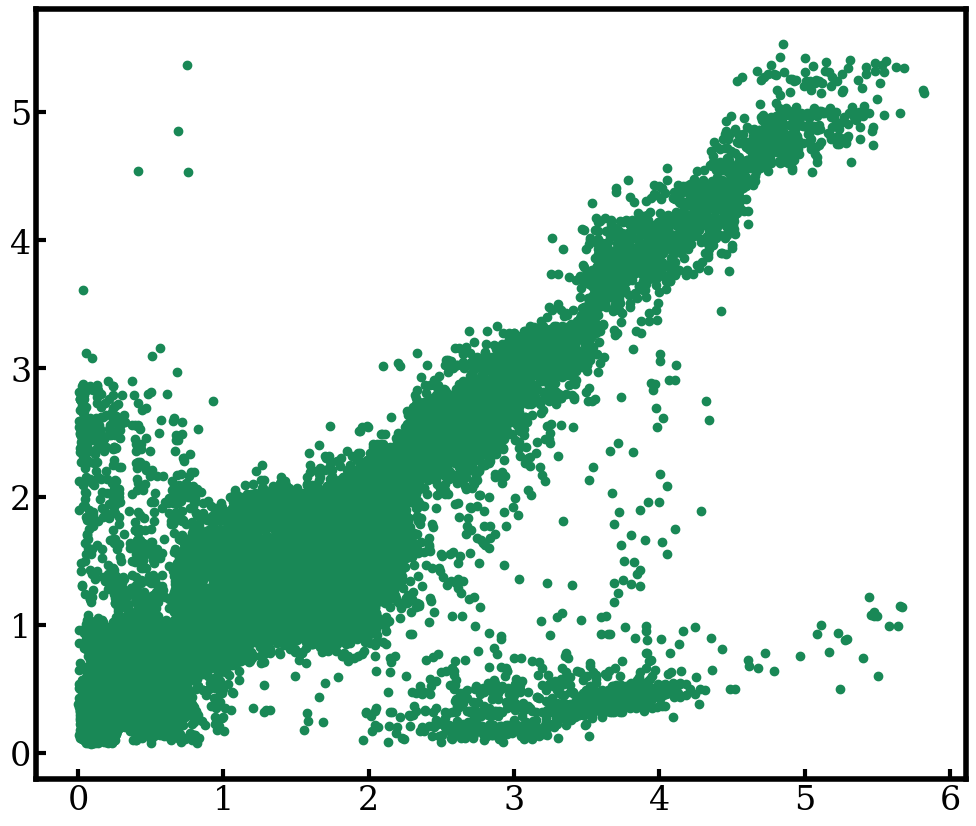

In [107]:
fig = plt.figure()
ax = fig.add_subplot()

ax.scatter(ESTIMATION_REDSHIFTS_UMAP,
           PHOTOZS_estimated_wSpecZs['z_phot_median'].values)

array([0.2 , 3.96, 2.01, ..., 1.53, 1.56, 1.22], shape=(50000,))

In [18]:
### Specify path to noiseless catalog and redshifts
noiseless_catalog_filepath = "/pscratch/sd/s/sajkov/data/integrated_catalog_23apr26.pq"
DATASET_popCosmos_full   = tables_io.read(noiseless_catalog_filepath)

### Number of pop-cosmos sources to use in analysis
training_cut   = 10_000   ### Number of sources used to train the estimators
estimation_cut = 50_000   ### Number of sources for which to estimate redshifts

### Randomize full dataset indices
len_DATASET_popCosmos_full = len(DATASET_popCosmos_full)
RANDIDX_popCosmos_full = rng.choice(np.arange(len_DATASET_popCosmos_full),
                                    len_DATASET_popCosmos_full,
                                    replace = False)

RANDIDX_DeepField_full, RANDIDX_WideFastDeep_full = np.array_split(RANDIDX_popCosmos_full, 2)

### Select needed bands and pick out needed sources
PHOTOMETRY_DeepField_noiseless    = DATASET_popCosmos_full[BANDS_DeepField].iloc[RANDIDX_DeepField_full]
PHOTOMETRY_WideFastDeep_noiseless = DATASET_popCosmos_full[BANDS_WideFastDeep].iloc[RANDIDX_WideFastDeep_full]

column_list None


In [19]:
### Noising parameters

nYrObs     = 1 # one-year depths
nVisYr     = 1 # one visit/yr (i.e., no co-adds)
gamma      = 0.04

In [20]:
M5_DEPTHS_DeepField = {'LSST_u'    : 27.74,
                      'LSST_g'    : 28.69,
                      'LSST_r'    : 28.88,
                      'LSST_i'    : 28.96,
                      'LSST_z'    : 28.26,
                      'LSST_y'    : 26.63,
                    #   'Roman_F062': 27.7,
                    #   'Roman_F087': 27.7,
                      'Roman_F106': 27.6,
                      'Roman_F129': 27.5,
                      'Roman_F158': 27.0,
                      'Roman_F184': 25.9,
                      'Roman_F213': 28.3,
                      'HSC_MB_00' : 26.41,
                      'HSC_MB_01' : 26.51,
                      'HSC_MB_02' : 26.45,
                      'HSC_MB_03' : 26.69,
                      'HSC_MB_04' : 26.93,
                      'HSC_MB_05' : 26.62,
                      'HSC_MB_06' : 26.26,
                      'HSC_MB_07' : 26.02,
                      'HSC_MB_08' : 26.07,
                      'HSC_MB_09' : 26.00,
                      'HSC_MB_10' : 26.06,
                      'HSC_MB_11' : 25.52,
                      'HSC_MB_12' : 25.58,
                      'HSC_MB_13' : 25.43,
                      'HSC_MB_14' : 25.15,
                      'HSC_MB_15' : 24.79}

iBandLimit_DeepField = 27.5

### 5-sigma limiting depths for WideFastDeep from https://usdf-maf.slac.stanford.edu/summaryStats?runId=5#Basics_Coadd%20M5
### Column `DD:WFD CoaddM5`
M5_DEPTHS_WideFastDeep = {'LSST_u'    : 25.61,
                          'LSST_g'    : 26.90,
                          'LSST_r'    : 26.87,
                          'LSST_i'    : 26.43,
                          'LSST_z'    : 25.73,
                          'LSST_y'    : 24.79}

iBandLimit_WideFastDeep = 25

BANDS_DeepField = list(M5_DEPTHS_DeepField.keys())
ERR_BANDS_DeepField = [f"{key}_err" for key in BANDS_DeepField]

BANDS_WideFastDeep = list(M5_DEPTHS_WideFastDeep.keys())
ERR_BANDS_WideFastDeep = [f"{key}_err" for key in BANDS_WideFastDeep]

In [64]:
sigLim = 1

getNoisyDeepFieldPhotometry_pogson = MultiSurveyErrorModel.make_stage(
    name = "getNoisyDeepFieldPhotometry_pogson",
    
    inputType  = "pogson",
    outputType = "pogson",
    
    m5     = M5_DEPTHS_DeepField,
    bands  = BANDS_DeepField,
    nYrObs = nYrObs,
    nVisYr = nVisYr,
    gamma  = gamma,
    sigLim = sigLim,
    
    seed = seed
)

getNoisyDeepFieldPhotometry_pogson.set_data("noiseless_catalog", PHOTOMETRY_DeepField_noiseless) 
getNoisyDeepFieldPhotometry_pogson.run()
PHOTOMETRY_DeepField_pogson_noisy_full = getNoisyDeepFieldPhotometry_pogson.get_handle("noisy_catalog").data
getNoisyDeepFieldPhotometry_pogson.finalize()

iBandCut_DeepField_pogson_noisy = PHOTOMETRY_DeepField_pogson_noisy_full["LSST_i"] < 27
PHOTOMETRY_DeepField_pogson_noisy_iBandCut = PHOTOMETRY_DeepField_pogson_noisy_full[iBandCut_DeepField_pogson_noisy]
PHOTOMETRY_DeepField_pogson_noisy_iBandCut_trainingCut = PHOTOMETRY_DeepField_pogson_noisy_iBandCut.iloc[:training_cut]

PHOTOMETRY_DeepField_pogson_noisy = PHOTOMETRY_DeepField_pogson_noisy_iBandCut_trainingCut

getNoisyWideFastDeepPhotometry_pogson = MultiSurveyErrorModel.make_stage(
    name = "getNoisyWideFastDeepPhotometry_pogson",
    
    inputType  = "pogson",
    outputType = "pogson",
    
    m5     = M5_DEPTHS_WideFastDeep,
    bands  = BANDS_WideFastDeep,
    nYrObs = nYrObs,
    nVisYr = nVisYr,
    gamma  = gamma,
    sigLim = sigLim,
    
    seed = seed
)

getNoisyWideFastDeepPhotometry_pogson.set_data("noiseless_catalog", PHOTOMETRY_WideFastDeep_noiseless) 
getNoisyWideFastDeepPhotometry_pogson.run()
PHOTOMETRY_WideFastDeep_pogson_noisy_full = getNoisyWideFastDeepPhotometry_pogson.get_handle("noisy_catalog").data
getNoisyWideFastDeepPhotometry_pogson.finalize()

iBandCut_WideFastDeep_pogson_noisy = PHOTOMETRY_WideFastDeep_pogson_noisy_full["LSST_i"] < 25
PHOTOMETRY_WideFastDeep_pogson_noisy_iBandCut = PHOTOMETRY_WideFastDeep_pogson_noisy_full[iBandCut_WideFastDeep_pogson_noisy]
PHOTOMETRY_WideFastDeep_pogson_noisy_iBandCut_trainingCut = PHOTOMETRY_WideFastDeep_pogson_noisy_iBandCut.iloc[:estimation_cut]

PHOTOMETRY_WideFastDeep_pogson_noisy = PHOTOMETRY_WideFastDeep_pogson_noisy_iBandCut_trainingCut

### Get source indices
IDX_popCosmos_DeepField_pogson             = list(PHOTOMETRY_DeepField_pogson_noisy.index)
IDX_popCosmos_WideFastDeep_pogson          = list(PHOTOMETRY_WideFastDeep_pogson_noisy.index)

PHOTOMETRY_DeepField_pogson_noisy    = PHOTOMETRY_DeepField_pogson_noisy.replace(np.inf, np.nan)
PHOTOMETRY_WideFastDeep_pogson_noisy = PHOTOMETRY_WideFastDeep_pogson_noisy.replace(np.inf, np.nan)


2026-07-10 11:54:10 [info     ] Inserting handle into data store.  noiseless_catalog: None, getNoisyDeepFieldPhotometry_pogson
2026-07-10 11:54:18 [info     ] Inserting handle into data store.  noisy_catalog_getNoisyDeepFieldPhotometry_pogson: inprogress_noisy_catalog_getNoisyDeepFieldPhotometry_pogson.pq, getNoisyDeepFieldPhotometry_pogson
2026-07-10 11:54:20 [info     ] Inserting handle into data store.  noiseless_catalog: None, getNoisyWideFastDeepPhotometry_pogson
2026-07-10 11:54:21 [info     ] Inserting handle into data store.  noisy_catalog_getNoisyWideFastDeepPhotometry_pogson: inprogress_noisy_catalog_getNoisyWideFastDeepPhotometry_pogson.pq, getNoisyWideFastDeepPhotometry_pogson


In [65]:
sigLim = 0

getNoisyDeepFieldPhotometry_asinh = MultiSurveyErrorModel.make_stage(
    name = "getNoisyDeepFieldPhotometry_asinh",
    
    inputType  = "pogson",
    outputType = "asinh",
    
    m5     = M5_DEPTHS_DeepField,
    bands  = BANDS_DeepField,
    nYrObs = nYrObs,
    nVisYr = nVisYr,
    gamma  = gamma,
    sigLim = sigLim,
    
    seed = seed
)

getNoisyDeepFieldPhotometry_asinh.set_data("noiseless_catalog", PHOTOMETRY_DeepField_noiseless) 
getNoisyDeepFieldPhotometry_asinh.run()
PHOTOMETRY_DeepField_asinh_noisy_full = getNoisyDeepFieldPhotometry_asinh.get_handle("noisy_catalog").data
getNoisyDeepFieldPhotometry_asinh.finalize()

# iBandCut_DeepField_asinh_noisy = PHOTOMETRY_DeepField_asinh_noisy_full["LSST_i"] < 27
PHOTOMETRY_DeepField_asinh_noisy_iBandCut = PHOTOMETRY_DeepField_asinh_noisy_full[iBandCut_DeepField_pogson_noisy]
PHOTOMETRY_DeepField_asinh_noisy_iBandCut_trainingCut = PHOTOMETRY_DeepField_asinh_noisy_iBandCut.iloc[:training_cut]

PHOTOMETRY_DeepField_asinh_noisy = PHOTOMETRY_DeepField_asinh_noisy_iBandCut_trainingCut

getNoisyWideFastDeepPhotometry_asinh = MultiSurveyErrorModel.make_stage(
    name = "getNoisyWideFastDeepPhotometry_asinh",
    
    inputType  = "pogson",
    outputType = "asinh",
    
    m5     = M5_DEPTHS_WideFastDeep,
    bands  = BANDS_WideFastDeep,
    nYrObs = nYrObs,
    nVisYr = nVisYr,
    gamma  = gamma,
    sigLim = sigLim,
    
    seed = seed
)

getNoisyWideFastDeepPhotometry_asinh.set_data("noiseless_catalog", PHOTOMETRY_WideFastDeep_noiseless) 
getNoisyWideFastDeepPhotometry_asinh.run()
PHOTOMETRY_WideFastDeep_asinh_noisy_full = getNoisyWideFastDeepPhotometry_asinh.get_handle("noisy_catalog").data
getNoisyWideFastDeepPhotometry_asinh.finalize()

# iBandCut_WideFastDeep_asinh_noisy = PHOTOMETRY_WideFastDeep_asinh_noisy_full["LSST_i"] < 25
PHOTOMETRY_WideFastDeep_asinh_noisy_iBandCut = PHOTOMETRY_WideFastDeep_asinh_noisy_full[iBandCut_WideFastDeep_pogson_noisy]
PHOTOMETRY_WideFastDeep_asinh_noisy_iBandCut_trainingCut = PHOTOMETRY_WideFastDeep_asinh_noisy_iBandCut.iloc[:estimation_cut]

PHOTOMETRY_WideFastDeep_asinh_noisy = PHOTOMETRY_WideFastDeep_asinh_noisy_iBandCut_trainingCut

### Get source indices
IDX_popCosmos_DeepField_asinh             = list(PHOTOMETRY_DeepField_asinh_noisy.index)
IDX_popCosmos_WideFastDeep_asinh          = list(PHOTOMETRY_WideFastDeep_asinh_noisy.index)

PHOTOMETRY_DeepField_asinh_noisy    = PHOTOMETRY_DeepField_asinh_noisy.replace(np.inf, np.nan)
PHOTOMETRY_WideFastDeep_asinh_noisy = PHOTOMETRY_WideFastDeep_asinh_noisy.replace(np.inf, np.nan)


2026-07-10 11:54:28 [info     ] Inserting handle into data store.  noiseless_catalog: None, getNoisyDeepFieldPhotometry_asinh
2026-07-10 11:54:38 [info     ] Inserting handle into data store.  noisy_catalog_getNoisyDeepFieldPhotometry_asinh: inprogress_noisy_catalog_getNoisyDeepFieldPhotometry_asinh.pq, getNoisyDeepFieldPhotometry_asinh
2026-07-10 11:54:40 [info     ] Inserting handle into data store.  noiseless_catalog: None, getNoisyWideFastDeepPhotometry_asinh
2026-07-10 11:54:42 [info     ] Inserting handle into data store.  noisy_catalog_getNoisyWideFastDeepPhotometry_asinh: inprogress_noisy_catalog_getNoisyWideFastDeepPhotometry_asinh.pq, getNoisyWideFastDeepPhotometry_asinh


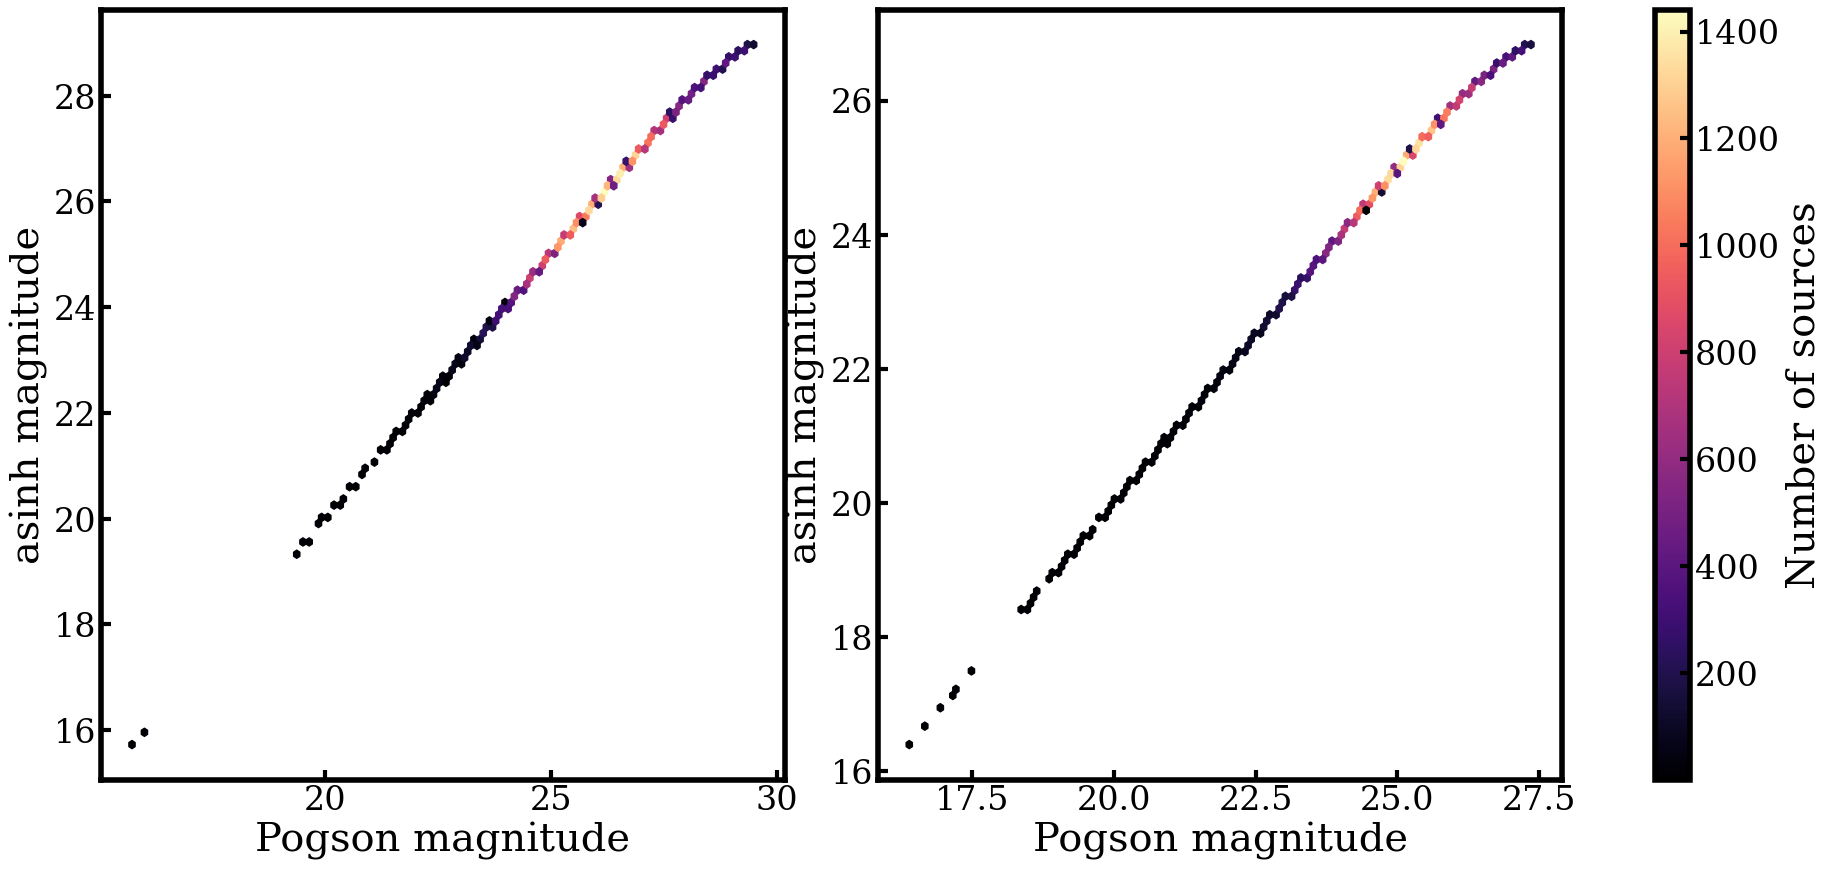

In [75]:
fig = plt.figure(figsize = (20.5, 10))
axs = fig.subplots(1, 3, width_ratios = (10, 10, 0.5))

band = "LSST_u"

axs[0].hexbin(PHOTOMETRY_DeepField_pogson_noisy[band], PHOTOMETRY_DeepField_asinh_noisy[band], mincnt = 1)
axs[0].set_xlabel("Pogson magnitude")
axs[0].set_ylabel("asinh magnitude")

mappable = axs[1].hexbin(PHOTOMETRY_WideFastDeep_pogson_noisy[band], PHOTOMETRY_WideFastDeep_asinh_noisy[band], mincnt = 1)
axs[1].set_xlabel("Pogson magnitude")
axs[1].set_ylabel("asinh magnitude")

fig.colorbar(mappable = mappable, cax = axs[2], label = "Number of sources")

In [53]:
M1_DEPTHS_DeepField = {key: float(np.round(M5_DEPTHS_DeepField[key] + 2.5 * np.log10(5), 2))\
                        for key in M5_DEPTHS_DeepField}

M1_DEPTHS_WideFastDeep = {key: float(np.round(M5_DEPTHS_WideFastDeep[key] + 2.5 * np.log10(5), 2))\
                            for key in M5_DEPTHS_WideFastDeep}

In [56]:
sigLim = 1

getNoisyDeepFieldPhotometry_pogson_M1 = MultiSurveyErrorModel.make_stage(
    name = "getNoisyDeepFieldPhotometry_pogson_M1",
    
    inputType  = "pogson",
    outputType = "pogson",
    
    m5     = M5_DEPTHS_DeepField,
    bands  = BANDS_DeepField,
    nYrObs = nYrObs,
    nVisYr = nVisYr,
    gamma  = gamma,
    sigLim = sigLim,
    
    seed = seed
)

getNoisyDeepFieldPhotometry_pogson_M1.set_data("noiseless_catalog", PHOTOMETRY_DeepField_noiseless) 
getNoisyDeepFieldPhotometry_pogson_M1.run()
PHOTOMETRY_DeepField_pogson_M1_noisy_full = getNoisyDeepFieldPhotometry_pogson_M1.get_handle("noisy_catalog").data
getNoisyDeepFieldPhotometry_pogson_M1.finalize()

iBandCut_DeepField_pogson_M1_noisy = PHOTOMETRY_DeepField_pogson_M1_noisy_full["LSST_i"] < 27
PHOTOMETRY_DeepField_pogson_M1_noisy_iBandCut = PHOTOMETRY_DeepField_pogson_M1_noisy_full[iBandCut_DeepField_pogson_M1_noisy]
PHOTOMETRY_DeepField_pogson_M1_noisy_iBandCut_trainingCut = PHOTOMETRY_DeepField_pogson_M1_noisy_iBandCut.iloc[:training_cut]

PHOTOMETRY_DeepField_pogson_M1_noisy = PHOTOMETRY_DeepField_pogson_M1_noisy_iBandCut_trainingCut

getNoisyWideFastDeepPhotometry_pogson_M1 = MultiSurveyErrorModel.make_stage(
    name = "getNoisyWideFastDeepPhotometry_pogson_M1",
    
    inputType  = "pogson",
    outputType = "pogson",
    
    m5     = M5_DEPTHS_WideFastDeep,
    bands  = BANDS_WideFastDeep,
    nYrObs = nYrObs,
    nVisYr = nVisYr,
    gamma  = gamma,
    sigLim = sigLim,
    
    seed = seed
)

getNoisyWideFastDeepPhotometry_pogson_M1.set_data("noiseless_catalog", PHOTOMETRY_WideFastDeep_noiseless) 
getNoisyWideFastDeepPhotometry_pogson_M1.run()
PHOTOMETRY_WideFastDeep_pogson_M1_noisy_full = getNoisyWideFastDeepPhotometry_pogson_M1.get_handle("noisy_catalog").data
getNoisyWideFastDeepPhotometry_pogson_M1.finalize()

iBandCut_WideFastDeep_pogson_M1_noisy = PHOTOMETRY_WideFastDeep_pogson_M1_noisy_full["LSST_i"] < 25
PHOTOMETRY_WideFastDeep_pogson_M1_noisy_iBandCut = PHOTOMETRY_WideFastDeep_pogson_M1_noisy_full[iBandCut_WideFastDeep_pogson_M1_noisy]
PHOTOMETRY_WideFastDeep_pogson_M1_noisy_iBandCut_trainingCut = PHOTOMETRY_WideFastDeep_pogson_M1_noisy_iBandCut.iloc[:estimation_cut]

PHOTOMETRY_WideFastDeep_pogson_M1_noisy = PHOTOMETRY_WideFastDeep_pogson_M1_noisy_iBandCut_trainingCut

### Get source indices
IDX_popCosmos_DeepField_pogson_M1             = list(PHOTOMETRY_DeepField_pogson_M1_noisy.index)
IDX_popCosmos_WideFastDeep_pogson_M1          = list(PHOTOMETRY_WideFastDeep_pogson_M1_noisy.index)

PHOTOMETRY_DeepField_pogson_M1_noisy    = PHOTOMETRY_DeepField_pogson_M1_noisy.replace(np.inf, np.nan)
PHOTOMETRY_WideFastDeep_pogson_M1_noisy = PHOTOMETRY_WideFastDeep_pogson_M1_noisy.replace(np.inf, np.nan)


2026-07-10 11:47:43 [info     ] Inserting handle into data store.  noiseless_catalog: None, getNoisyDeepFieldPhotometry_pogson_M1
2026-07-10 11:47:51 [info     ] Inserting handle into data store.  noisy_catalog_getNoisyDeepFieldPhotometry_pogson_M1: inprogress_noisy_catalog_getNoisyDeepFieldPhotometry_pogson_M1.pq, getNoisyDeepFieldPhotometry_pogson_M1
2026-07-10 11:47:54 [info     ] Inserting handle into data store.  noiseless_catalog: None, getNoisyWideFastDeepPhotometry_pogson_M1
2026-07-10 11:47:56 [info     ] Inserting handle into data store.  noisy_catalog_getNoisyWideFastDeepPhotometry_pogson_M1: inprogress_noisy_catalog_getNoisyWideFastDeepPhotometry_pogson_M1.pq, getNoisyWideFastDeepPhotometry_pogson_M1


In [62]:
sigLim = 0

getNoisyDeepFieldPhotometry_asinh_M1 = MultiSurveyErrorModel.make_stage(
    name = "getNoisyDeepFieldPhotometry_asinh_M1",
    
    inputType  = "pogson",
    outputType = "asinh",
    
    m5     = M1_DEPTHS_DeepField,
    bands  = BANDS_DeepField,
    nYrObs = nYrObs,
    nVisYr = nVisYr,
    gamma  = gamma,
    sigLim = sigLim,
    
    seed = seed
)

getNoisyDeepFieldPhotometry_asinh_M1.set_data("noiseless_catalog", PHOTOMETRY_DeepField_noiseless) 
getNoisyDeepFieldPhotometry_asinh_M1.run()
PHOTOMETRY_DeepField_asinh_M1_noisy_full = getNoisyDeepFieldPhotometry_asinh_M1.get_handle("noisy_catalog").data
getNoisyDeepFieldPhotometry_asinh_M1.finalize()

iBandCut_DeepField_asinh_M1_noisy = PHOTOMETRY_DeepField_asinh_M1_noisy_full["LSST_i"] < 27
PHOTOMETRY_DeepField_asinh_M1_noisy_iBandCut = PHOTOMETRY_DeepField_asinh_M1_noisy_full[iBandCut_DeepField_pogson_M1_noisy]
PHOTOMETRY_DeepField_asinh_M1_noisy_iBandCut_trainingCut = PHOTOMETRY_DeepField_asinh_M1_noisy_iBandCut.iloc[:training_cut]

PHOTOMETRY_DeepField_asinh_M1_noisy = PHOTOMETRY_DeepField_asinh_M1_noisy_iBandCut_trainingCut

getNoisyWideFastDeepPhotometry_asinh_M1 = MultiSurveyErrorModel.make_stage(
    name = "getNoisyWideFastDeepPhotometry_asinh_M1",
    
    inputType  = "pogson",
    outputType = "asinh",
    
    m5     = M1_DEPTHS_WideFastDeep,
    bands  = BANDS_WideFastDeep,
    nYrObs = nYrObs,
    nVisYr = nVisYr,
    gamma  = gamma,
    sigLim = sigLim,
    
    seed = seed
)

getNoisyWideFastDeepPhotometry_asinh_M1.set_data("noiseless_catalog", PHOTOMETRY_WideFastDeep_noiseless) 
getNoisyWideFastDeepPhotometry_asinh_M1.run()
PHOTOMETRY_WideFastDeep_asinh_M1_noisy_full = getNoisyWideFastDeepPhotometry_asinh_M1.get_handle("noisy_catalog").data
getNoisyWideFastDeepPhotometry_asinh_M1.finalize()

# iBandCut_WideFastDeep_asinh_M1_noisy = PHOTOMETRY_WideFastDeep_asinh_M1_noisy_full["LSST_i"] < 25
PHOTOMETRY_WideFastDeep_asinh_M1_noisy_iBandCut = PHOTOMETRY_WideFastDeep_asinh_M1_noisy_full[iBandCut_WideFastDeep_pogson_M1_noisy]
PHOTOMETRY_WideFastDeep_asinh_M1_noisy_iBandCut_trainingCut = PHOTOMETRY_WideFastDeep_asinh_M1_noisy_iBandCut.iloc[:estimation_cut]

PHOTOMETRY_WideFastDeep_asinh_M1_noisy = PHOTOMETRY_WideFastDeep_asinh_M1_noisy_iBandCut_trainingCut

### Get source indices
IDX_popCosmos_DeepField_asinh_M1    = list(PHOTOMETRY_DeepField_asinh_M1_noisy.index)
IDX_popCosmos_WideFastDeep_asinh_M1 = list(PHOTOMETRY_WideFastDeep_asinh_M1_noisy.index)

PHOTOMETRY_DeepField_asinh_M1_noisy    = PHOTOMETRY_DeepField_asinh_M1_noisy.replace(np.inf, np.nan)
PHOTOMETRY_WideFastDeep_asinh_M1_noisy = PHOTOMETRY_WideFastDeep_asinh_M1_noisy.replace(np.inf, np.nan)


2026-07-10 11:52:41 [info     ] Inserting handle into data store.  noiseless_catalog: None, getNoisyDeepFieldPhotometry_asinh_M1
2026-07-10 11:52:51 [info     ] Inserting handle into data store.  noisy_catalog_getNoisyDeepFieldPhotometry_asinh_M1: inprogress_noisy_catalog_getNoisyDeepFieldPhotometry_asinh_M1.pq, getNoisyDeepFieldPhotometry_asinh_M1
2026-07-10 11:52:53 [info     ] Inserting handle into data store.  noiseless_catalog: None, getNoisyWideFastDeepPhotometry_asinh_M1
2026-07-10 11:52:55 [info     ] Inserting handle into data store.  noisy_catalog_getNoisyWideFastDeepPhotometry_asinh_M1: inprogress_noisy_catalog_getNoisyWideFastDeepPhotometry_asinh_M1.pq, getNoisyWideFastDeepPhotometry_asinh_M1


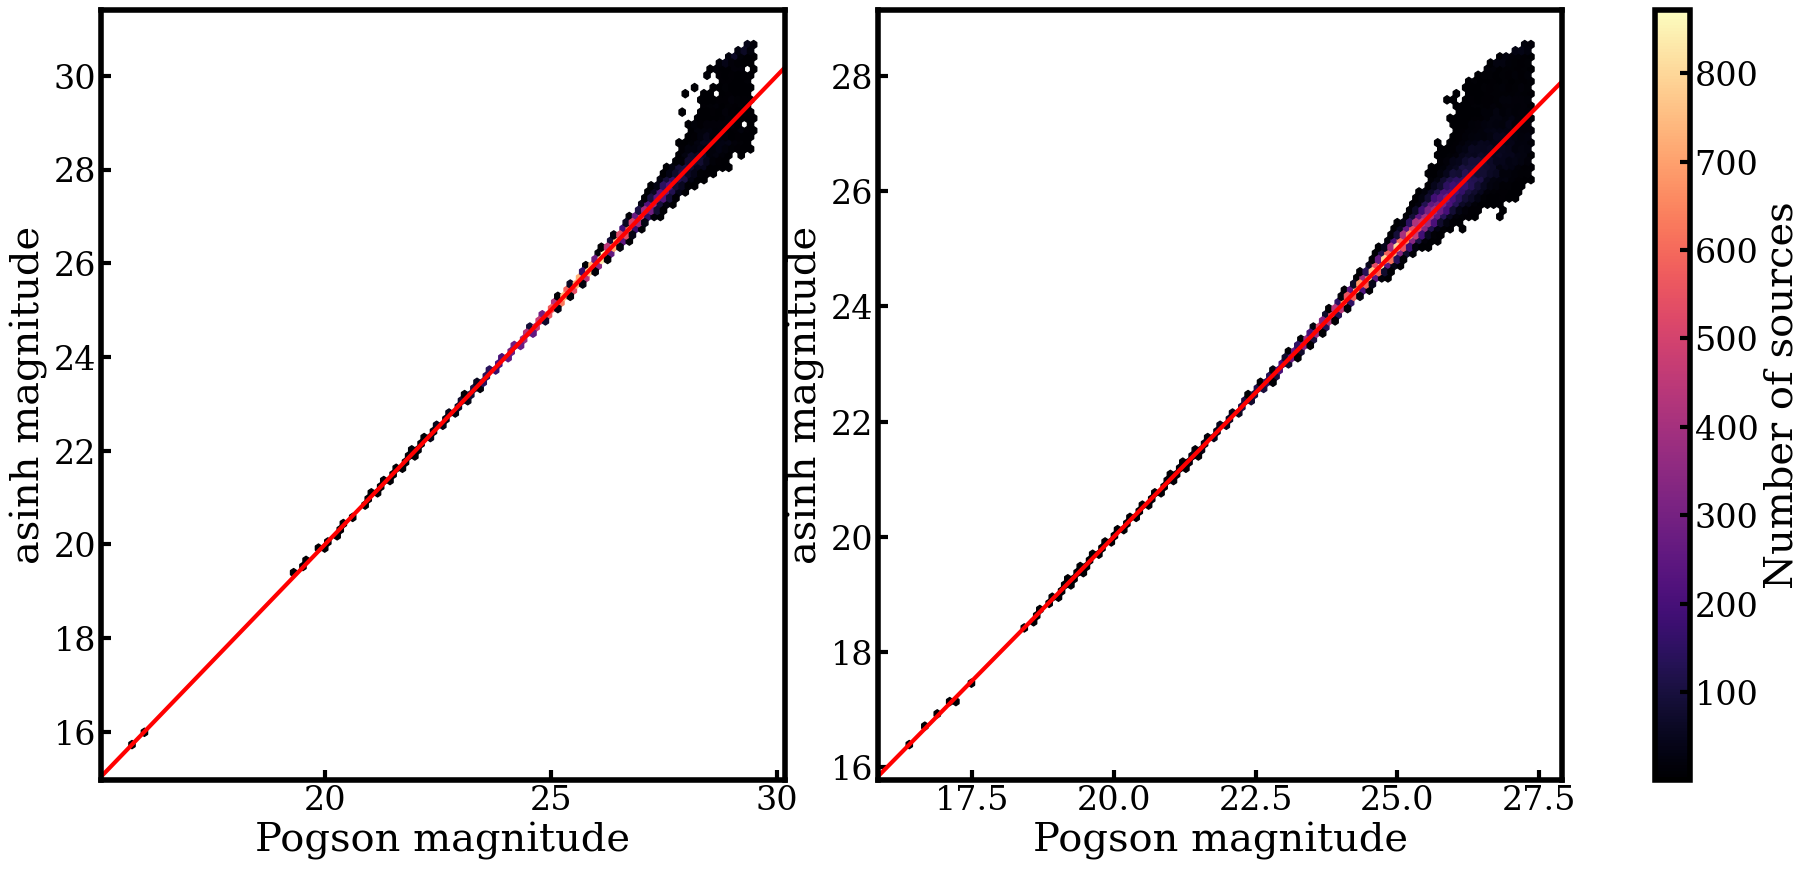

In [63]:
fig = plt.figure(figsize = (20.5, 10))
axs = fig.subplots(1, 3, width_ratios = [10, 10, .5])

axs[0].hexbin(PHOTOMETRY_DeepField_pogson_M1_noisy["LSST_u"], PHOTOMETRY_DeepField_asinh_M1_noisy["LSST_u"],
              mincnt = 1)
axs[0].axline([25, 25], slope = 1, color = "red")
axs[0].set_xlabel("Pogson magnitude")
axs[0].set_ylabel("asinh magnitude")

mappable = axs[1].hexbin(PHOTOMETRY_WideFastDeep_pogson_M1_noisy["LSST_u"], PHOTOMETRY_WideFastDeep_asinh_M1_noisy["LSST_u"],
              mincnt = 1)
axs[1].axline([25, 25], slope = 1, color = "red")
axs[1].set_xlabel("Pogson magnitude")
axs[1].set_ylabel("asinh magnitude")

fig.colorbar(mappable = mappable, cax = axs[2], label = 'Number of sources')

In [3]:
PHOTOMETRY_DeepField_noisy_AB = tables_io.read("/pscratch/sd/s/sajkov/analysis_pipeline/runs/draft_UMAP_fix/PHOTOMETRY_DeepField_noisy_AB_draft_UMAP_fix.pq")
PHOTOMETRY_DeepField_noisy_asinh = tables_io.read("/pscratch/sd/s/sajkov/analysis_pipeline/runs/draft_UMAP_fix/PHOTOMETRY_DeepField_noisy_asinh_draft_UMAP_fix.pq")

PHOTOMETRY_WideFastDeep_noisy_AB = tables_io.read("/pscratch/sd/s/sajkov/analysis_pipeline/runs/draft_UMAP_fix/PHOTOMETRY_WideFastDeep_noisy_AB_draft_UMAP_fix.pq")
PHOTOMETRY_WideFastDeep_noisy_asinh = tables_io.read("/pscratch/sd/s/sajkov/analysis_pipeline/runs/draft_UMAP_fix/PHOTOMETRY_WideFastDeep_noisy_asinh_draft_UMAP_fix.pq")


column_list None
column_list None
column_list None
column_list None


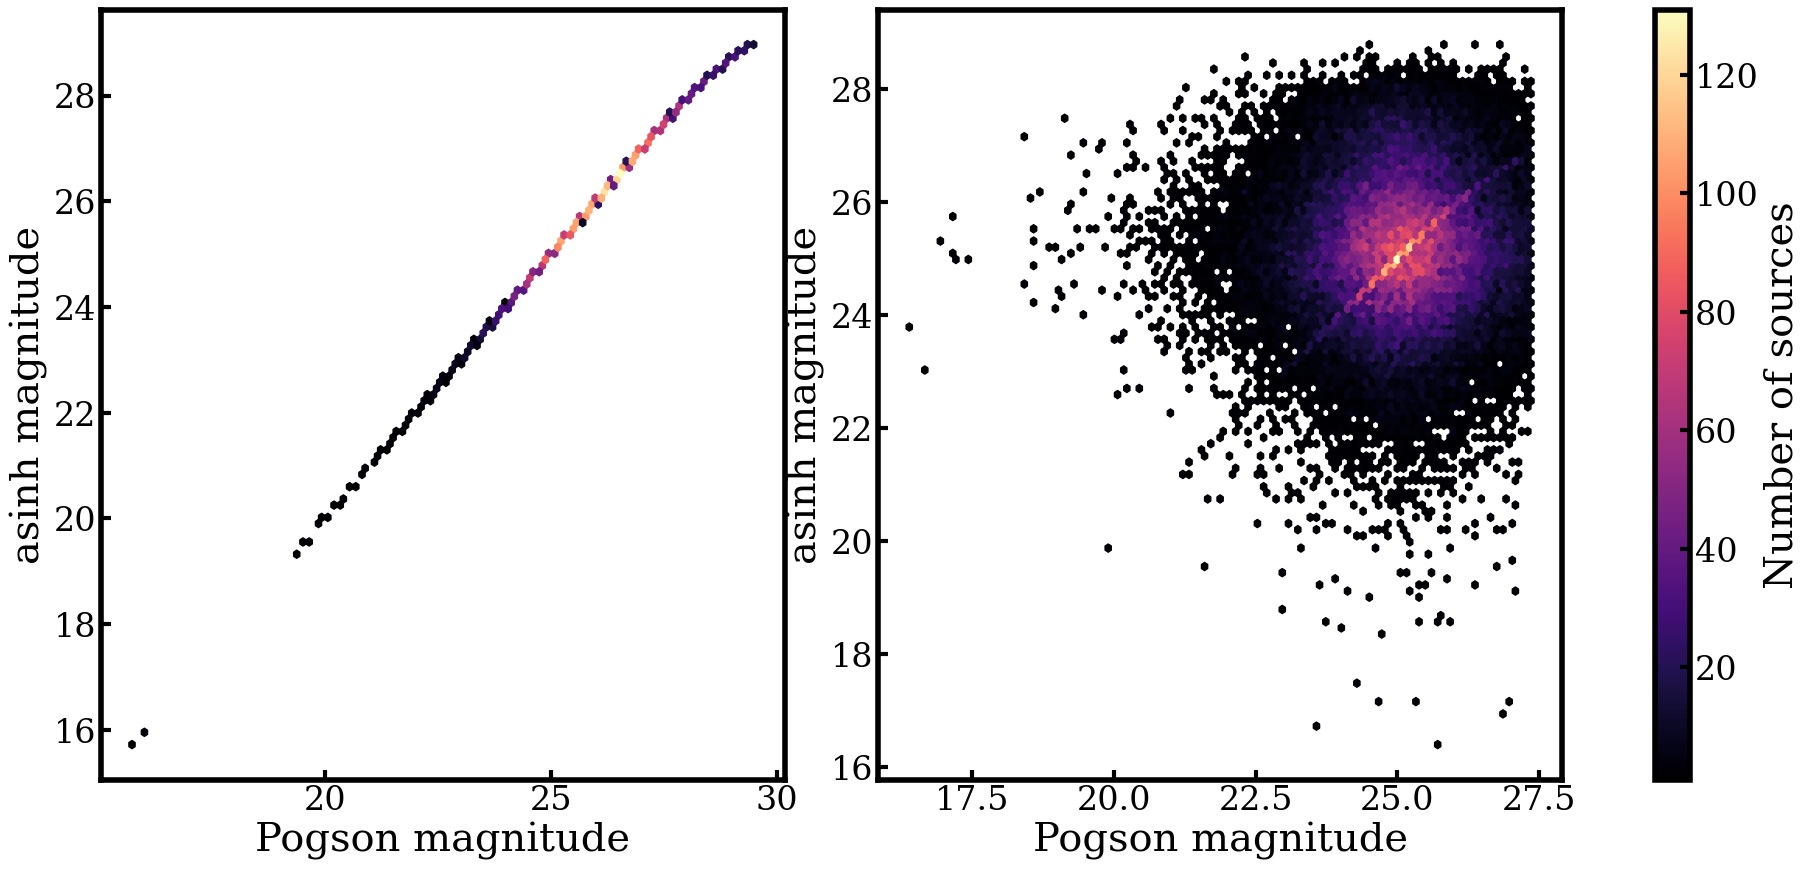

In [4]:
fig = plt.figure(figsize = (20.5, 10))
axs = fig.subplots(1, 3, width_ratios = [10, 10, .5])

axs[0].hexbin(PHOTOMETRY_DeepField_noisy_AB["LSST_u"], PHOTOMETRY_DeepField_noisy_asinh["LSST_u"],
              mincnt = 1)
axs[0].set_xlabel("Pogson magnitude")
axs[0].set_ylabel("asinh magnitude")

mappable = axs[1].hexbin(PHOTOMETRY_WideFastDeep_noisy_AB["LSST_u"], PHOTOMETRY_WideFastDeep_noisy_asinh["LSST_u"],
              mincnt = 1)
axs[1].set_xlabel("Pogson magnitude")
axs[1].set_ylabel("asinh magnitude")

fig.colorbar(mappable = mappable, cax = axs[2], label = 'Number of sources')

In [1]:
fig = plt.figure(figsize = (20.5, 10))
axs = fig.subplots(1, 3, width_ratios = [10, 10, .5])

axs[0].hexbin(PHOTOMETRY_DeepField_noisy_AB["LSST_i"], PHOTOMETRY_DeepField_noisy_asinh["LSST_i"],
              mincnt = 1)
axs[0].set_xlabel("Pogson magnitude")
axs[0].set_ylabel("asinh magnitude")

mappable = axs[1].hexbin(PHOTOMETRY_WideFastDeep_noisy_AB["LSST_i"], PHOTOMETRY_WideFastDeep_noisy_asinh["LSST_i"],
              mincnt = 1)
axs[1].set_xlabel("Pogson magnitude")
axs[1].set_ylabel("asinh magnitude")

fig.colorbar(mappable = mappable, cax = axs[2], label = 'Number of sources')

NameError: name 'plt' is not defined